In [1]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 976.9/976.9 kB 17.4 MB/s eta 0:00:0000:01


In [2]:
data_yaml = """
train: /kaggle/input/clc-yolo-xray/train
val: /kaggle/input/clc-yolo-xray/valid/images
test: /kaggle/input/clc-yolo-xray/test/images

nc: 13
names: ['gun-knife-wrench-pilers-scissors', 'Cans', 'CartonDrinks', 'GlassBottle', 'PlasticBottle', 'SprayCans', 'SwissArmyKnife', 'Tin', 'VacuumCup', 'blade', 'dagger', 'knife', 'scissors']
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(data_yaml)

In [3]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
model = YOLO("yolov9m.pt")

100%|██████████| 39.1M/39.1M [00:00<00:00, 228MB/s]


In [5]:
model.train(
    data="/kaggle/working/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    project="/kaggle/working/yolo_results",
    name="clc-xray-yolov9m",
    exist_ok=True,
    task="detect"
)

Ultralytics 8.3.99 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov9m.pt, data=/kaggle/working/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=/kaggle/working/yolo_results, name=clc-xray-yolov9m, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_label

100%|██████████| 755k/755k [00:00<00:00, 17.8MB/s]


Overriding model.yaml nc=80 with nc=13

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1    171648  ultralytics.nn.modules.block.RepNCSPELAN4    [64, 128, 128, 64, 1]         
  3                  -1  1    276960  ultralytics.nn.modules.block.AConv           [128, 240]                    
  4                  -1  1    629520  ultralytics.nn.modules.block.RepNCSPELAN4    [240, 240, 240, 120, 1]       
  5                  -1  1    778320  ultralytics.nn.modules.block.AConv           [240, 360]                    
  6                  -1  1   1414080  ultralytics.nn.modules.block.RepNCSPELAN4    [360, 360, 360, 180, 1]       
  7                  -1  1   1556160  ultralytic

100%|██████████| 5.35M/5.35M [00:00<00:00, 73.6MB/s]


AMP: checks passed ✅


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 30/30 [00:15<00:00,  2.00it/s]


                   all        956       2317       0.91      0.856      0.889      0.788
                  Cans         83         87      0.943      0.839      0.912      0.832
          CartonDrinks        208        228      0.982      0.966      0.992       0.86
           GlassBottle         32         45      0.381      0.156      0.182      0.147
         PlasticBottle        462        607       0.92       0.88      0.935      0.839
             SprayCans         87         96      0.849      0.703      0.811      0.693
        SwissArmyKnife        113        114      0.991      0.939      0.969      0.779
                   Tin         82         93      0.944      0.904      0.936       0.83
             VacuumCup        182        192      0.953      0.964       0.98      0.892
                 blade        263        398      0.988      0.962      0.989      0.807
                dagger        121        122      0.984          1      0.991      0.939
                 knif

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 11.3ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/yolo_results/clc-xray-yolov9m


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d8bed4c1480>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

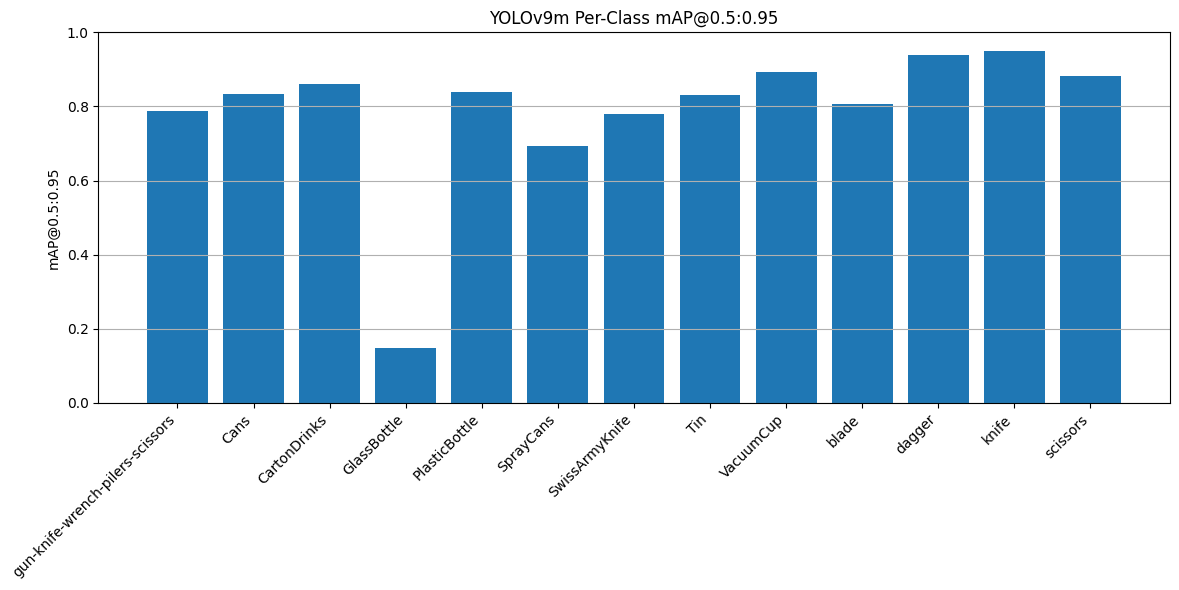

In [6]:
 import matplotlib.pyplot as plt
import numpy as np

# Class names and mAP@0.5:0.95 values
names = {
    0: 'gun-knife-wrench-pilers-scissors',
    1: 'Cans',
    2: 'CartonDrinks',
    3: 'GlassBottle',
    4: 'PlasticBottle',
    5: 'SprayCans',
    6: 'SwissArmyKnife',
    7: 'Tin',
    8: 'VacuumCup',
    9: 'blade',
    10: 'dagger',
    11: 'knife',
    12: 'scissors'
}

maps = np.array([
    0.78761, 0.83237, 0.85988, 0.14659, 0.83903, 0.69348, 0.77936,
    0.83041, 0.89234, 0.80676, 0.93919, 0.94917, 0.88277
])

# Plot
plt.figure(figsize=(12, 6))
plt.bar(names.values(), maps)
plt.ylabel("mAP@0.5:0.95")
plt.title("YOLOv9m Per-Class mAP@0.5:0.95")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


In [9]:
from ultralytics import YOLO

model = YOLO("/kaggle/input/yolov11n.pt/pytorch/default/1/yolov11n.pt")  # You can also use yolov11s.pt, yolov11m.pt, etc.

model.train(
    data="/kaggle/working/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    project="/kaggle/working/yolo_results",
    name="clc-xray-yolov11n",
    exist_ok=True,
    task="detect"
)


Ultralytics 8.3.99 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=/kaggle/input/yolov11n.pt/pytorch/default/1/yolov11n.pt, data=/kaggle/working/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=/kaggle/working/yolo_results, name=clc-xray-yolov11n, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False

train: Scanning /kaggle/input/clc-yolo-xray/train/labels... 3186 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3186/3186 [00:04<00:00, 760.01it/s]


train: WARNING ⚠️ Cache directory /kaggle/input/clc-yolo-xray/train is not writeable, cache not saved.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /kaggle/input/clc-yolo-xray/valid/labels... 956 images, 0 backgrounds, 0 corrupt: 100%|██████████| 956/956 [00:02<00:00, 446.70it/s]

val: WARNING ⚠️ Cache directory /kaggle/input/clc-yolo-xray/valid is not writeable, cache not saved.


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 30/30 [00:06<00:00,  4.37it/s]


                   all        956       2317      0.878      0.828      0.858      0.739
                  Cans         83         87      0.944      0.828      0.868      0.764
          CartonDrinks        208        228      0.985      0.947      0.989      0.841
           GlassBottle         32         45      0.105     0.0667     0.0627     0.0481
         PlasticBottle        462        607      0.907      0.837      0.908      0.781
             SprayCans         87         96      0.859      0.635      0.725      0.624
        SwissArmyKnife        113        114      0.964      0.956       0.97       0.76
                   Tin         82         93      0.924      0.839      0.894       0.78
             VacuumCup        182        192      0.907      0.938      0.947      0.834
                 blade        263        398      0.986      0.937      0.975      0.748
                dagger        121        122      0.967          1      0.991      0.913
                 knif

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 1.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/yolo_results/clc-xray-yolov11n


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d8edbd46fe0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  